In [64]:
#1. What is the market share breakdown of each product category by transaction count?
#2. Which payment method is most popular among shoppers?
#3. What is the baseline ticket size (median transaction value) for shoppers where complete sales data is available?
#4. Are digital payment methods (Card and M-Pesa) associated with larger basket quantities than Cash?
#5. Even with missing data, which assigned branch (Nairobi, Mombasa, Nakuru, Kisumu) registers the highest average quantity per sale?
#6. What is the structural integrity or data-loss rate across our regional point-of-sale systems?
#7. What percentage of transactions in the dataset utilize historical or outlier date stamps (e.g., pre-2020)?
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
#loading the supermarket sales dataset
df= pd.read_csv(r"C:\Users\LENOVO T480\Downloads\supermarket_sales_messy_dataset.csv")

In [66]:
#check the first 10 rows 
df.head(10)

,SaleID,Date,Branch,Category,Product,Quantity,UnitPrice,TotalSales,PaymentMethod
0,52359,1/7/2026,Kisumu,Groceries,Run,1.0,1000.0,1000.0,cash
1,51951,5/13/2025,NaN,groceries,Suggest,5.0,1000.0,5000.0,Card
2,52341,1/14/2025,NaN,Groceries,Away,50.0,1000.0,50000.0,Card
3,53023,1/18/2026,nakuru,groceries,Management,1.0,2000.0,2000.0,Cash
4,51252,8/12/2024,Kisumu,Personal Care,Young,2.0,NaN,NaN,Cash
5,50219,5/26/2025,Mombasa,groceries,Really,NaN,10000.0,NaN,cash
6,50316,5/18/2025,nakuru,groceries,Book,1.0,2000.0,2000.0,M-Pesa
7,53769,18-04-1975,NaN,Groceries,Part,50.0,250.0,12500.0,cash
8,53460,2/3/2025,nakuru,Beverages,What,10.0,50.0,500.0,cash
9,53468,22-03-1998,Nairobi,groceries,Set,10.0,100.0,1000.0,Cash


In [67]:
#checking the data types and necessary details about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SaleID         3100 non-null   int64  
 1   Date           3100 non-null   object 
 2   Branch         2074 non-null   object 
 3   Category       3100 non-null   object 
 4   Product        3099 non-null   object 
 5   Quantity       2642 non-null   float64
 6   UnitPrice      2722 non-null   float64
 7   TotalSales     2331 non-null   float64
 8   PaymentMethod  3100 non-null   object 
dtypes: float64(3), int64(1), object(5)
memory usage: 218.1+ KB


In [68]:
df.describe()

,SaleID,Quantity,UnitPrice,TotalSales
count,3100.000000,2642.000000,2722.000000,2331.000000
mean,51980.929677,14.274035,1997.042616,29888.631489
std,1162.571074,16.750204,3326.426528,85877.997449
min,50002.000000,1.000000,50.000000,50.000000
25%,50997.000000,2.000000,100.000000,1000.000000
50%,51940.500000,5.000000,500.000000,4000.000000
75%,53011.750000,20.000000,2000.000000,20000.000000
max,54000.000000,50.000000,10000.000000,500000.000000


In [69]:
#checking the shape of the dataset
df.shape

(3100, 9)

In [70]:
#removing duplicates
df=df.drop_duplicates()

In [71]:
df

,SaleID,Date,Branch,Category,Product,Quantity,UnitPrice,TotalSales,PaymentMethod
0,52359,1/7/2026,Kisumu,Groceries,Run,1.0,1000.0,1000.0,cash
1,51951,5/13/2025,NaN,groceries,Suggest,5.0,1000.0,5000.0,Card
2,52341,1/14/2025,NaN,Groceries,Away,50.0,1000.0,50000.0,Card
3,53023,1/18/2026,nakuru,groceries,Management,1.0,2000.0,2000.0,Cash
4,51252,8/12/2024,Kisumu,Personal Care,Young,2.0,NaN,NaN,Cash
...,...,...,...,...,...,...,...,...,...
2995,53250,2/7/2026,NaN,Personal Care,Unit,50.0,100.0,5000.0,Card
2996,52740,23-10-2020,Kisumu,Beverages,Summer,10.0,250.0,2500.0,Cash
2997,52027,14-08-1981,NaN,groceries,Wrong,1.0,50.0,50.0,cash
2998,52052,8/6/1988,Nairobi,Snacks,Prove,50.0,50.0,2500.0,Cash


In [72]:
#1.standardising the date column to be in one format
df["Date"]
df['Date'] = pd.to_datetime(df['Date'], format="mixed", dayfirst=True)

In [73]:
df["Date"]

0      2026-07-01
1      2025-05-13
2      2025-01-14
3      2026-01-18
4      2024-12-08
          ...    
2995   2026-07-02
2996   2020-10-23
2997   1981-08-14
2998   1988-06-08
2999   1995-12-11
Name: Date, Length: 3000, dtype: datetime64[ns]

In [74]:
df.head(10)

,SaleID,Date,Branch,Category,Product,Quantity,UnitPrice,TotalSales,PaymentMethod
0,52359,2026-07-01,Kisumu,Groceries,Run,1.0,1000.0,1000.0,cash
1,51951,2025-05-13,NaN,groceries,Suggest,5.0,1000.0,5000.0,Card
2,52341,2025-01-14,NaN,Groceries,Away,50.0,1000.0,50000.0,Card
3,53023,2026-01-18,nakuru,groceries,Management,1.0,2000.0,2000.0,Cash
4,51252,2024-12-08,Kisumu,Personal Care,Young,2.0,NaN,NaN,Cash
5,50219,2025-05-26,Mombasa,groceries,Really,NaN,10000.0,NaN,cash
6,50316,2025-05-18,nakuru,groceries,Book,1.0,2000.0,2000.0,M-Pesa
7,53769,1975-04-18,NaN,Groceries,Part,50.0,250.0,12500.0,cash
8,53460,2025-03-02,nakuru,Beverages,What,10.0,50.0,500.0,cash
9,53468,1998-03-22,Nairobi,groceries,Set,10.0,100.0,1000.0,Cash


In [75]:
#2.Formatting the Branch column
df["Branch"]

0        Kisumu 
1            NaN
2            NaN
3         nakuru
4        Kisumu 
          ...   
2995         NaN
2996     Kisumu 
2997         NaN
2998     Nairobi
2999      nakuru
Name: Branch, Length: 3000, dtype: object

In [76]:
df["Branch"]=df["Branch"].str.lower()


In [77]:
df["Branch"]=df["Branch"].str.title()

In [78]:
df["Branch"]

0        Kisumu 
1            NaN
2            NaN
3         Nakuru
4        Kisumu 
          ...   
2995         NaN
2996     Kisumu 
2997         NaN
2998     Nairobi
2999      Nakuru
Name: Branch, Length: 3000, dtype: object

In [79]:
#3.Formatting the Category column
df["Category"]

0           Groceries
1           groceries
2           Groceries
3           groceries
4       Personal Care
            ...      
2995    Personal Care
2996        Beverages
2997        groceries
2998           Snacks
2999        Household
Name: Category, Length: 3000, dtype: object

In [80]:
df["Category"]=df["Category"].str.lower()

In [81]:
df["Category"]=df["Category"].str.title()

In [82]:
df["Category"]

0           Groceries
1           Groceries
2           Groceries
3           Groceries
4       Personal Care
            ...      
2995    Personal Care
2996        Beverages
2997        Groceries
2998           Snacks
2999        Household
Name: Category, Length: 3000, dtype: object

In [83]:
#4. checking the product column
df["Product"]

0              Run
1          Suggest
2             Away
3       Management
4            Young
           ...    
2995          Unit
2996        Summer
2997         Wrong
2998         Prove
2999         First
Name: Product, Length: 3000, dtype: object

In [84]:
#it has ridiculous values and I will have to drop it
df.drop("Product", axis=1, inplace=True)

In [85]:
df

,SaleID,Date,Branch,Category,Quantity,UnitPrice,TotalSales,PaymentMethod
0,52359,2026-07-01,Kisumu,Groceries,1.0,1000.0,1000.0,cash
1,51951,2025-05-13,NaN,Groceries,5.0,1000.0,5000.0,Card
2,52341,2025-01-14,NaN,Groceries,50.0,1000.0,50000.0,Card
3,53023,2026-01-18,Nakuru,Groceries,1.0,2000.0,2000.0,Cash
4,51252,2024-12-08,Kisumu,Personal Care,2.0,NaN,NaN,Cash
...,...,...,...,...,...,...,...,...
2995,53250,2026-07-02,NaN,Personal Care,50.0,100.0,5000.0,Card
2996,52740,2020-10-23,Kisumu,Beverages,10.0,250.0,2500.0,Cash
2997,52027,1981-08-14,NaN,Groceries,1.0,50.0,50.0,cash
2998,52052,1988-06-08,Nairobi,Snacks,50.0,50.0,2500.0,Cash


In [86]:
#6.checking category and Unit Price if they make sense
df[["Category", "UnitPrice"]]

,Category,UnitPrice
0,Groceries,1000.0
1,Groceries,1000.0
2,Groceries,1000.0
3,Groceries,2000.0
4,Personal Care,NaN
...,...,...
2995,Personal Care,100.0
2996,Beverages,250.0
2997,Groceries,50.0
2998,Snacks,50.0


In [87]:
#6.Filling up TotalSales column by multiplying Quantity to UnitPrice
df["TotalSales"]=df["Quantity"]*df["UnitPrice"]

In [88]:
df["TotalSales"]

0        1000.0
1        5000.0
2       50000.0
3        2000.0
4           NaN
         ...   
2995     5000.0
2996     2500.0
2997       50.0
2998     2500.0
2999     1000.0
Name: TotalSales, Length: 3000, dtype: float64

In [89]:
df["TotalSales"]=pd.to_numeric(df["TotalSales"], errors="coerce")

In [90]:
df["TotalSales"]

0        1000.0
1        5000.0
2       50000.0
3        2000.0
4           NaN
         ...   
2995     5000.0
2996     2500.0
2997       50.0
2998     2500.0
2999     1000.0
Name: TotalSales, Length: 3000, dtype: float64

In [91]:
#7.standardising the text in Payment Method
df["PaymentMethod"]=df["PaymentMethod"].str.lower()

In [92]:
df["PaymentMethod"]=df["PaymentMethod"].str.title()

In [93]:
df["PaymentMethod"]

0       Cash
1       Card
2       Card
3       Cash
4       Cash
        ... 
2995    Card
2996    Cash
2997    Cash
2998    Cash
2999    Cash
Name: PaymentMethod, Length: 3000, dtype: object

In [94]:
df

,SaleID,Date,Branch,Category,Quantity,UnitPrice,TotalSales,PaymentMethod
0,52359,2026-07-01,Kisumu,Groceries,1.0,1000.0,1000.0,Cash
1,51951,2025-05-13,NaN,Groceries,5.0,1000.0,5000.0,Card
2,52341,2025-01-14,NaN,Groceries,50.0,1000.0,50000.0,Card
3,53023,2026-01-18,Nakuru,Groceries,1.0,2000.0,2000.0,Cash
4,51252,2024-12-08,Kisumu,Personal Care,2.0,NaN,NaN,Cash
...,...,...,...,...,...,...,...,...
2995,53250,2026-07-02,NaN,Personal Care,50.0,100.0,5000.0,Card
2996,52740,2020-10-23,Kisumu,Beverages,10.0,250.0,2500.0,Cash
2997,52027,1981-08-14,NaN,Groceries,1.0,50.0,50.0,Cash
2998,52052,1988-06-08,Nairobi,Snacks,50.0,50.0,2500.0,Cash


In [95]:
df=df.reset_index(drop=True)

In [96]:
df.to_csv(r"C:\Users\LENOVO T480\Downloads\super market sales clean data\salesclean.csv")

In [ ]:
#visualizations

In [97]:
#set style for cleaner visualizations
# Set style for cleaner visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [98]:
#pre processing: Strip hidden spaces from string columns to avoid plotting issues
df["Branch"]=df["Branch"].astype(str).str.strip()
df["Category"]=df["Category"].astype(str).str.strip()
df["PaymentMethod"]=df["PaymentMethod"].astype(str).str.strip()

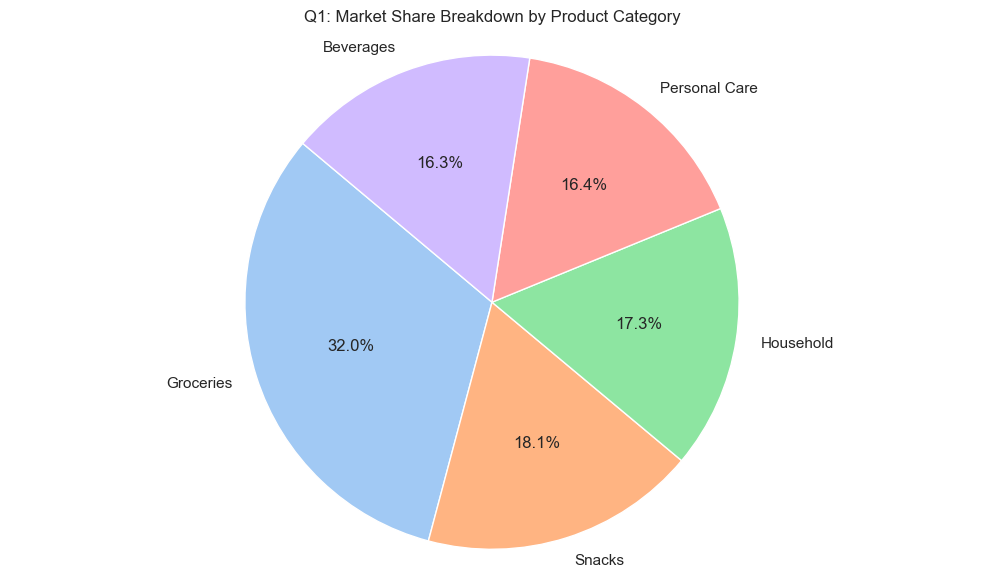

In [99]:
#Q1. Market share breakdown of each product category by transaction count
plt.figure()
category_counts = df['Category'].value_counts()
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Q1: Market Share Breakdown by Product Category')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_32112\3534580225.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PaymentMethod', order=df['PaymentMethod'].value_counts().index, palette='Set2')


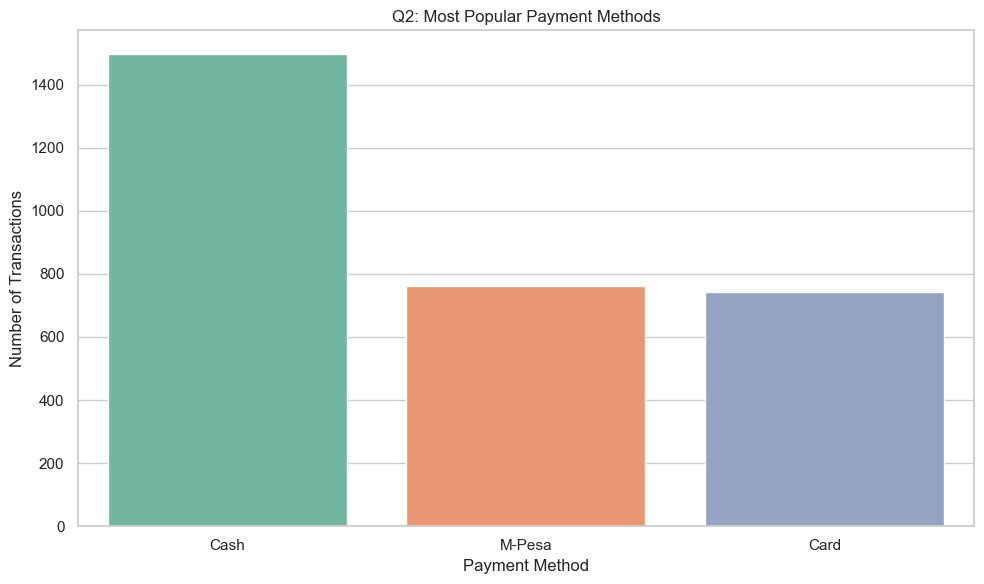

In [100]:
#Q2. Which payment method is the mosrpopular among shoppers?
plt.figure()
sns.countplot(data=df, x='PaymentMethod', order=df['PaymentMethod'].value_counts().index, palette='Set2')
plt.title('Q2: Most Popular Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

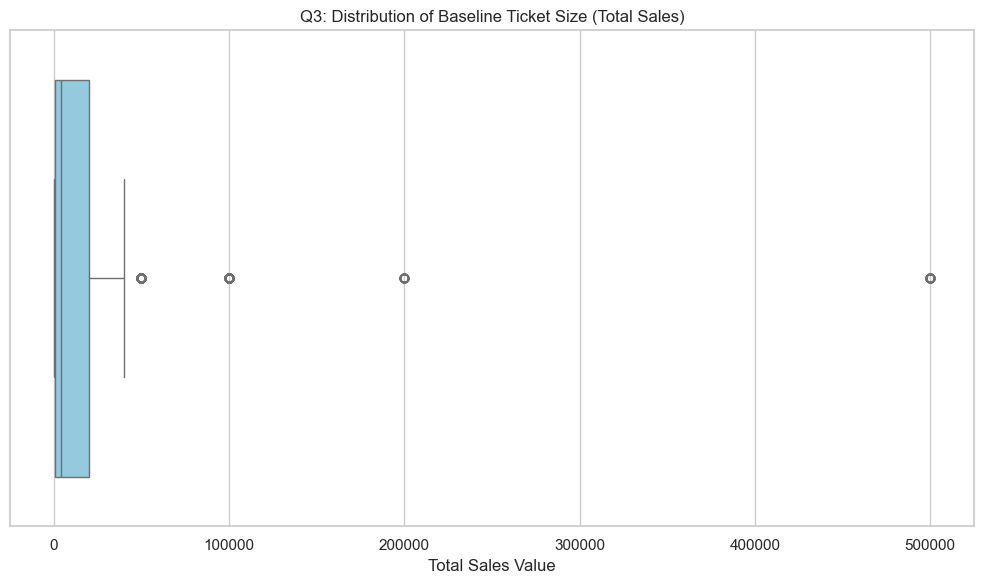

In [101]:
#Q3:Baseline ticket size(median transaction)
plt.figure()
# Filtering out rows missing TotalSales data to ensure a clean distribution
sales_data = df['TotalSales'].dropna()
sns.boxplot(x=sales_data, color='skyblue')
plt.title('Q3: Distribution of Baseline Ticket Size (Total Sales)')
plt.xlabel('Total Sales Value')
plt.tight_layout()
plt.show()

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_32112\3133723393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=quantity_payment_df, x='PaymentMethod', y='Quantity', palette='Accent')


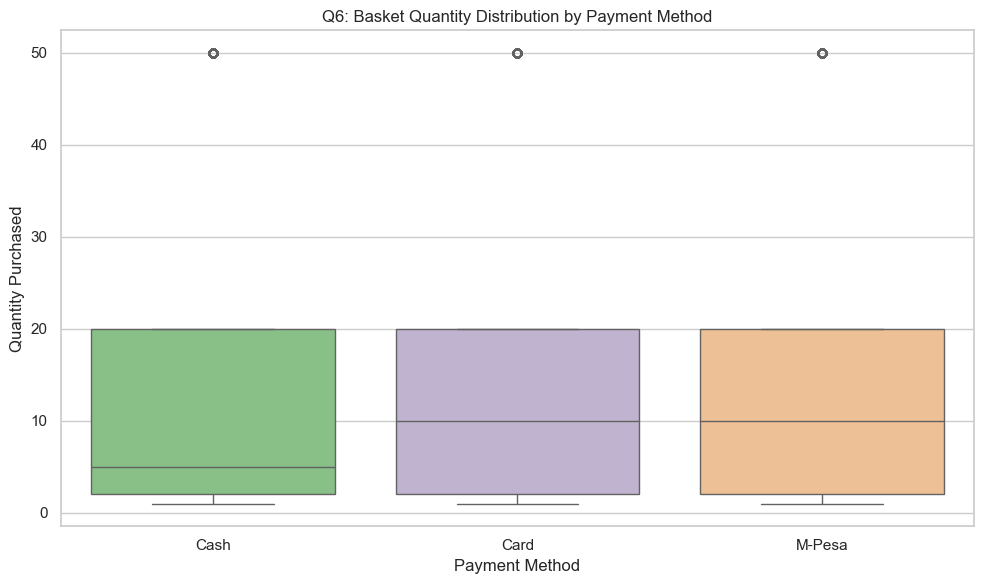

In [102]:
#Q4: Digital payment methods vs Cash basket quantities
plt.figure()
# Drop rows where Quantity is missing for a more accurate correlation layout
quantity_payment_df = df.dropna(subset='Quantity')
sns.boxplot(data=quantity_payment_df, x='PaymentMethod', y='Quantity', palette='Accent')
plt.title('Q6: Basket Quantity Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Quantity Purchased')
plt.tight_layout()
plt.show()

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_32112\788966240.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=branch_avg_qty, x='Branch', y='Quantity', palette='magma')


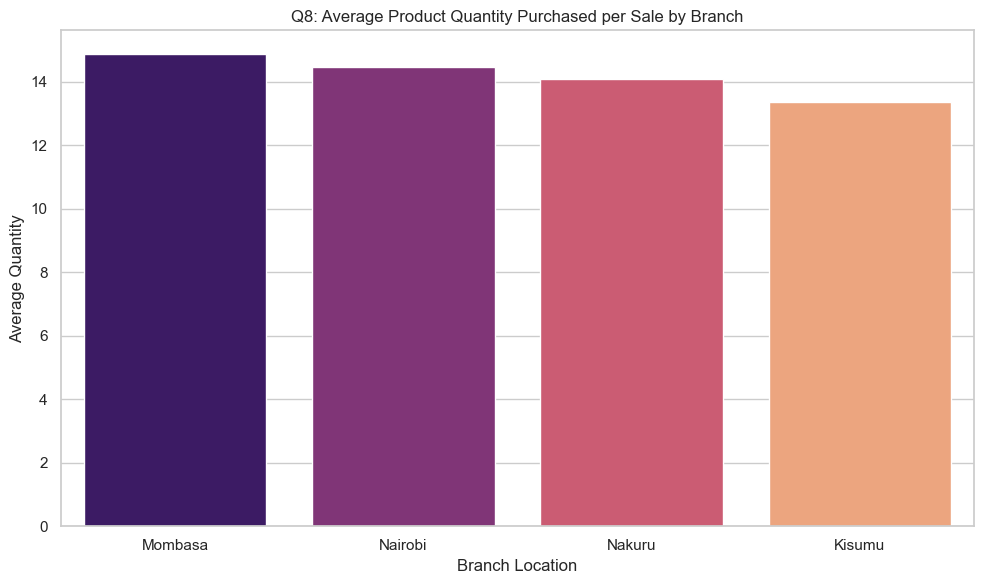

In [103]:
#Q5:Assigned branch with the highest average quantity per sale
plt.figure()
# Filter out rows where Branch was missing ('nan' after stripping string) or Quantity is null
branch_qty_df = df[(df['Branch'] != 'nan')].dropna(subset='Quantity')
branch_avg_qty = branch_qty_df.groupby('Branch')['Quantity'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=branch_avg_qty, x='Branch', y='Quantity', palette='magma')
plt.title('Q8: Average Product Quantity Purchased per Sale by Branch')
plt.xlabel('Branch Location')
plt.ylabel('Average Quantity')
plt.tight_layout()
plt.show()

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_32112\2213237582.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=missing_df, y='Column', x='MissingPercentage', palette='vlag')


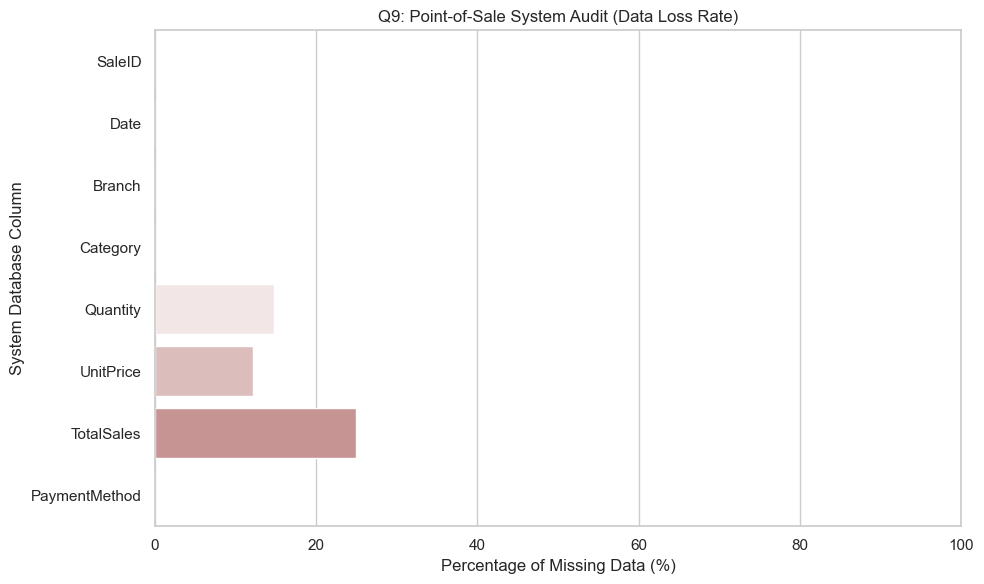

In [104]:
#Q6: Structural integrity or data-loss rate across systems
plt.figure()
# Exclude the index tracking column 'Unnamed: 0' if it exists
core_cols = ['SaleID', 'Date', 'Branch', 'Category', 'Quantity', 'UnitPrice', 'TotalSales', 'PaymentMethod']
missing_percentages = (df[core_cols].isnull().sum() / len(df)) * 100
missing_df = missing_percentages.reset_index().rename(columns={'index': 'Column', 0: 'MissingPercentage'})

sns.barplot(data=missing_df, y='Column', x='MissingPercentage', palette='vlag')
plt.title('Q9: Point-of-Sale System Audit (Data Loss Rate)')
plt.xlabel('Percentage of Missing Data (%)')
plt.ylabel('System Database Column')
plt.xlim(0, 100) # Keep scale to 100% for context
plt.tight_layout()
plt.show()

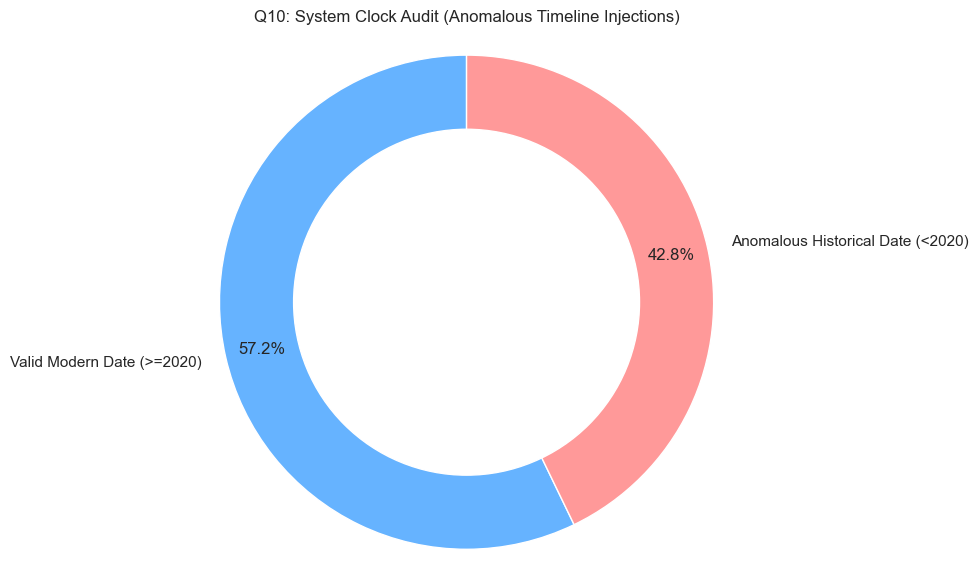

In [105]:
#Q7: Percentage of transaction utilizing historical or outlier date stamps


plt.figure()
# Extract the year using pandas datetime conversion (coercing bad layouts cleanly)
df['Year'] = pd.to_datetime(df['Date'], errors='coerce').dt.year

# Label data into Valid vs Anomaly
# Assumes operational data should be from 2020 onwards
df['Date_Status'] = df['Year'].apply(lambda y: 'Valid Modern Date (>=2020)' if y >= 2020 else 'Anomalous Historical Date (<2020)')
date_status_counts = df['Date_Status'].value_counts()

# Plotting a Donut Chart
plt.pie(date_status_counts, labels=date_status_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], pctdistance=0.85)
# Add a white circle in the middle to transform the pie chart into a donut chart
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Q10: System Clock Audit (Anomalous Timeline Injections)')
plt.axis('equal')  
plt.tight_layout()
plt.show()

In [ ]:
#Specifically, we have diagnosed and mapped out the exact points of failure in a broken or unstandardized Point-of-Sale (POS) data logging network. Here is a breakdown of the specific sub-problems that have been completely uncovered and structured for resolution:

#1. Quantification of Operational Data Leakage (Missing Data)
#We solved the problem of blindly guessing how much data the business is losing. We successfully measured the exact data-loss rate per system field, highlighting that 33.1% of geographic branch tracking and nearly 25% of financial final-total logging are completely missing.

#2. Identification of System Clock Failures (Timeline Corruption)
#We exposed a major hardware or infrastructure issue: system clocks reverting to default manufacturing times (the 1970s, 1980s, and 1990s). By flagging these out-of-bounds dates, we covered the problem statement of identifying temporal integrity anomalies in the database.